This notebook extends H_E_graph.ipynb to constrained problems

Finding good hyperparameters can be really hard and in this case we need to figure out how much to "constrain" the system. Too little mixing and our proposal mechanism does not find good, distant, configurations but not enough mixing and few proposals are valid states for the Markov chain to explore. In this notebook we touch on how to balance mixing and constraining our quantum state.

In [1]:
# imports
import itertools
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import joblib

# imports from qemcmc
from qemcmc.model import EnergyModel, ConstraintModel,ModelMaker
from qemcmc.sampler import QeProposal, ClassicalProposal
from qemcmc.coarse_grain import CoarseGraining


# Initialise Constrained Model
First we initialise an unconstrained random fully connected Ising model


In [2]:
n_spins = 9  # Number of spins in the system

base_model  = ModelMaker(n_spins, "Fully Connected Ising", "example model").model

Then we have to define the constraints

In [ ]:


shape_of_J = (n_spins, n_spins)
J_constraint = np.zeros(shape_of_J)
#J_constraint[-2, -1] = 1
#J_constraint[-1, -2] = 1
for i in range(n_spins):
    for j in range(i+1, n_spins):
        u = np.random.uniform(0, 1)
        if u < 0.1:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1
# To ensure non-constant constraint
J_constraint[0,1] = 1
J_constraint[1,0] = 1

def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]


    return sum == 0


then we define the contstraints model, with constraint energy defined by J_constraint and problem energy by h, J defined in  base_model

In [4]:
constraint_model = ConstraintModel(n_spins, constraint_couplings = [J_constraint,], couplings = base_model.couplings, name="Constraint Model", cost_function_signs=base_model.cost_function_signs, constraint_func=constraint_checker_func, constraint_signs = [1,])

# Classical understanding of the problem 

In [5]:
# (Classically) calculate energies of all configurations
all_energies = base_model.get_all_energies()


# (Classically) calculate the energy differences for all pairs of configurations
# And the Hamming distances for all pairs of configurations
S = base_model.S#np.array([np.binary_repr(s, width=n_spins) for s in range(2**n_spins)])
S_integer_arr = np.array([[int(bit) for bit in state] for state in S])
E_s = np.array(all_energies)







# Find the order of Energies in the original configuration space
E_order = np.argsort(E_s)


# find matrices of Energy differences of the configurations
E_diffs = np.zeros((2**n_spins, 2**n_spins))
hamming_dists = np.zeros((2**n_spins, 2**n_spins))
for s in S:
    for s_prime in S:
        hamming_dist = np.sum(np.bitwise_xor(S_integer_arr[int(s, 2)], S_integer_arr[int(s_prime, 2)]))
        E_diff = abs(E_s[int(s, 2)] - E_s[int(s_prime, 2)])
        E_diffs[int(s, 2), int(s_prime, 2)] = E_diff
        hamming_dists[int(s, 2), int(s_prime, 2)] = hamming_dist


# Find matrices of hamming distances of the configurations
hamming_distances = np.zeros_like(E_diffs)
for i, s in enumerate(tqdm.tqdm(S)):
    for j, s_prime in enumerate(S):
        #if constraint_checker_func(s):
        hamming_distances[int(i),:] = np.sum(np.bitwise_xor(S_integer_arr[int(s, 2)], S_integer_arr), axis=1)
    hamming_distances_ordered = hamming_distances[E_order, :][:, E_order]
time = 5







100%|██████████| 512/512 [00:18<00:00, 28.43it/s]


plot the Hamming distance matrix, where the configurations are ordered by energy

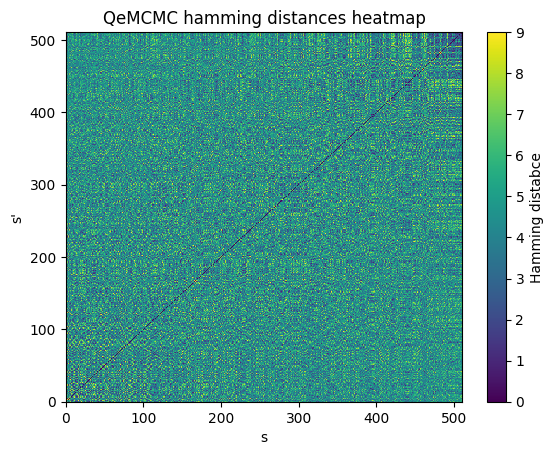

In [6]:

h_dists_flat = hamming_distances_ordered.flatten()


plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=h_dists_flat)#, norm="log")

plt.title("QeMCMC hamming distances heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Hamming distabce")
plt.show()

lets reorder the configrations, so that valid configurations are first, and replot the hamming distances. You'll see via the red dotted lines that only a small portion of configurations are valid

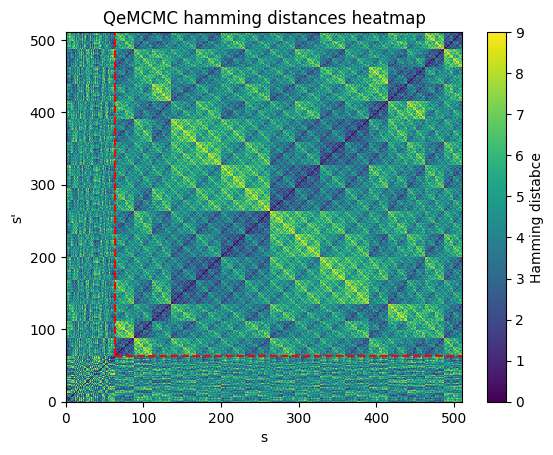

In [7]:

# Find the order, where the valid configurations (those that satisfy the constraints) are at the front, and the invalid ones are at the back
E_unconstrained_order = np.argsort(E_s)
E_s_constrained = np.array([E_s_ if constraint_checker_func(S[i]) else 1000 for i, E_s_ in enumerate(E_s)])
E_s_constrained_order = np.argsort(E_s_constrained)
number_valid_configs = np.sum(E_s_constrained < 99)
# plot the proposals between s and s', where the color is the haming distance
h_dists_ordered_constrained = hamming_distances[E_s_constrained_order, :][:, E_s_constrained_order]


plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
h_dists_constrained_flat = h_dists_ordered_constrained.flatten()

plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=h_dists_constrained_flat)#, norm="log")

plt.title("QeMCMC hamming distances heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Hamming distabce")
plt.show()


Lets "zoom in" on the s that are valid, and you should see some structure in the valid configurations. The invalid and valid configurations are demarked by the red line again

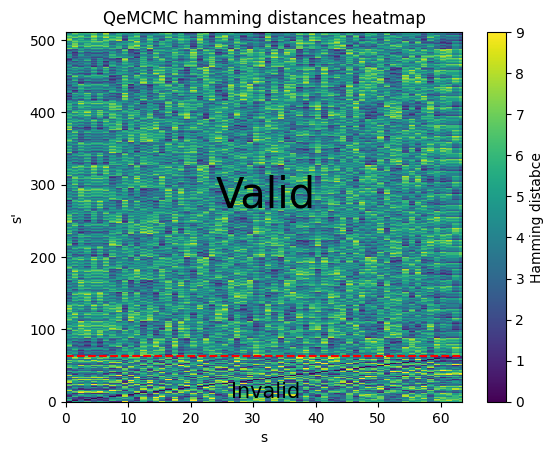

In [8]:
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=h_dists_constrained_flat)#, norm="log")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.title("QeMCMC hamming distances heatmap")

# write valid and invalid to make it clear which is which on the plot
plt.text(number_valid_configs/2, 2**(n_spins-1), "Valid", ha='center', va='bottom', color='k', size = 30)
plt.text(number_valid_configs/2, 0, "Invalid", ha='center', va='bottom', color='k', size=15)  

plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Hamming distabce")
plt.show()

# Simulate classical proposals

Using classical_mcmc, lets generate the proposal distruibutions

100%|██████████| 512/512 [00:01<00:00, 272.72it/s]


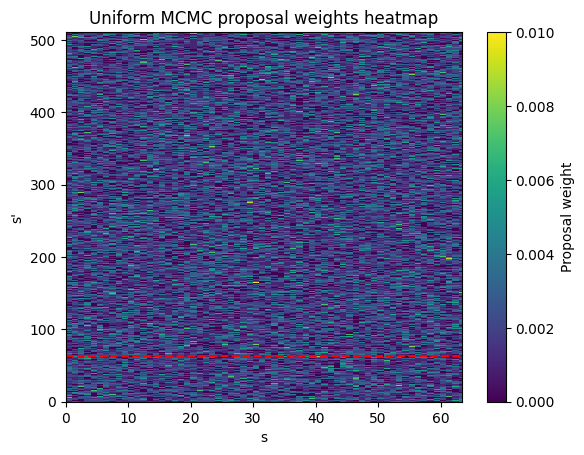

probability of proposing an invalid configuration with uniform proposal:  0.8753750000000001


In [9]:
# How many times to sample each proposal
reps = 1000

uniform_proposal = ClassicalProposal(constraint_model,method = "uniform")
uniform_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = uniform_proposal.update(s)
            state_int = int(state, 2)
            uniform_weights_sample[i, state_int] += 1
uniform_weights_sample = uniform_weights_sample / (reps)
uniform_weights_sample_ordered = uniform_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]




plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=uniform_weights_sample_ordered.flatten())#, norm="log")
plt.title("Uniform MCMC proposal weights heatmap")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

print("probability of proposing an invalid configuration with uniform proposal: ", np.sum(uniform_weights_sample[:, number_valid_configs:]) / np.sum(uniform_weights_sample))

100%|██████████| 512/512 [00:01<00:00, 400.21it/s]


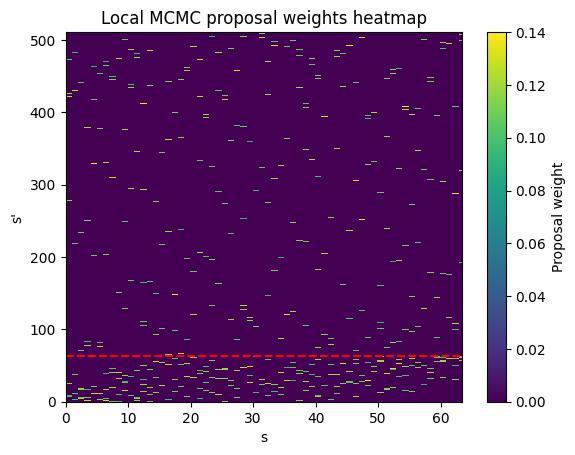

probability of proposing an invalid configuration with local proposal:  0.80609375


In [10]:
# How many times to sample each proposal
reps = 1000
local_proposal = ClassicalProposal(constraint_model, method = "local")
local_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = local_proposal.update(s)
            state_int = int(state, 2)
            local_weights_sample[i, state_int] += 1
local_weights_sample = local_weights_sample / (reps)
local_weights_sample_ordered = local_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]




plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=local_weights_sample_ordered.flatten())#, norm="log")
plt.title("Local MCMC proposal weights heatmap")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

print("probability of proposing an invalid configuration with local proposal: ", np.sum(local_weights_sample[:, number_valid_configs:]) / np.sum(local_weights_sample))

The uniform proposal of course has a very uniform distribution, while the local proposal has a sparse and structured distribution. Note that the configurations are ordered (on both axis) by their energy.
Of course, both methods perform many invalid proposals (those which start in a valid configuration, s, and transition to an invalid configuration, s')

# Quantum-enhanced proposals

Lets see how the quantum proposal distribution looks. First, lets ignore the constraints wrt. QeMCMC

In [11]:
# QeMCMC parameters
gamma = 0.45
time = 10

100%|██████████| 512/512 [01:07<00:00,  7.61it/s]


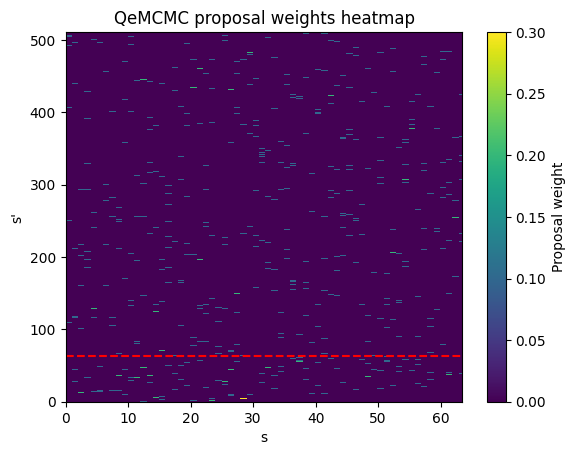

probability of proposing an invalid configuration with qemcmc proposal:  0.7781250000000001


In [12]:
# How many times to sample each proposal
reps = 10
# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(base_model, gamma=gamma, time=time, coupling_weights=[0.3,0.3])
qemcmc_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = quantum_proposal.update(s)
            state_int = int(state, 2)
            qemcmc_weights_sample[i, state_int] += 1
qemcmc_weights_sample = qemcmc_weights_sample / (reps)

qemcmc_weights_sample_ordered = qemcmc_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic

plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_sample_ordered.flatten())#, norm="log")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

print("probability of proposing an invalid configuration with qemcmc proposal: ", np.sum(qemcmc_weights_sample_ordered[:, number_valid_configs:]) / np.sum(qemcmc_weights_sample_ordered))

Again, there are many unwanted transitions to invalid configurations.

# Constrained Qe proposal

100%|██████████| 512/512 [00:58<00:00,  8.75it/s]


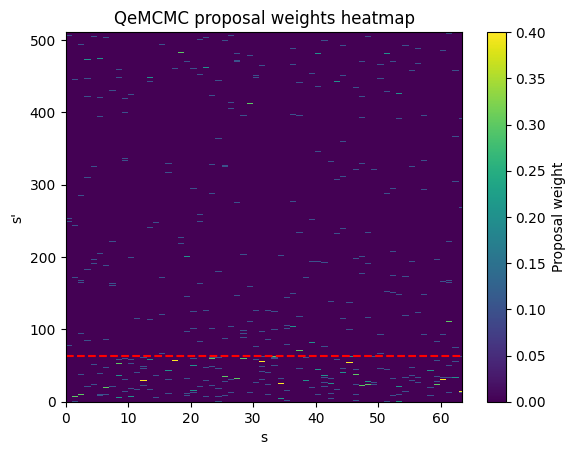

probability of proposing an invalid configuration with qe constrained proposal:  0.5234375


In [13]:
# How many times to sample each proposal
reps = 10
# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, coupling_weights=np.array([0.1,0.1,0.6])/(1-gamma))
qemcmc_constr_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = quantum_proposal.update(s)
            state_int = int(state, 2)
            qemcmc_constr_weights_sample[i, state_int] += 1
qemcmc_constr_weights_sample = qemcmc_constr_weights_sample / (reps)

qemcmc_constr_weights_sample_ordered = qemcmc_constr_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_constr_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()


print("probability of proposing an invalid configuration with qe constrained proposal: ", np.sum(qemcmc_constr_weights_sample_ordered[:, number_valid_configs:]) / np.sum(qemcmc_constr_weights_sample))


switch to state vector simulation to speed things up (instead of sampling)

100%|██████████| 512/512 [00:06<00:00, 81.61it/s] 


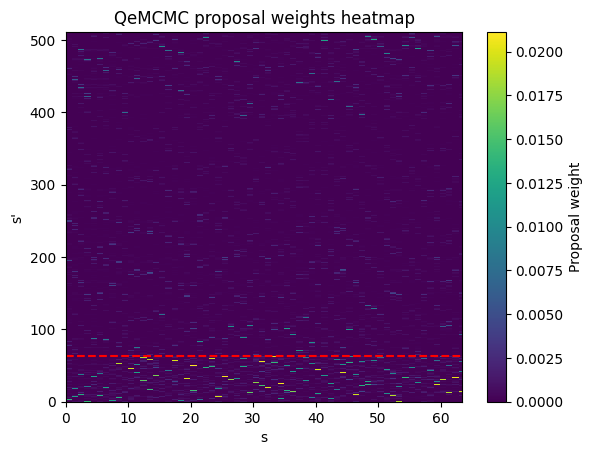

probability of proposing an invalid configuration with qe constrained proposal:  0.5487412460633136


In [14]:
# How many times to sample each proposal
reps = 10
# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, coupling_weights=[0.1,0.1,0.6])
qemcmc_constr_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):

        probabilities = np.abs(quantum_proposal.CM.get_state_vector(s, quantum_proposal.coupling_weights, time, quantum_proposal.gamma)) ** 2
        qemcmc_constr_weights_sample[int(i),:] += probabilities
qemcmc_constr_weights_sample = qemcmc_constr_weights_sample / (reps)

qemcmc_constr_weights_sample_ordered = qemcmc_constr_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_constr_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()


print("probability of proposing an invalid configuration with qe constrained proposal: ", np.sum(qemcmc_constr_weights_sample_ordered[:, number_valid_configs:]) / np.sum(qemcmc_constr_weights_sample))


How do we know how much weight to apply to the constraint Hamiltonian? Lets do a simple experiment to find a decent value

In [ ]:

self_proposals_percent_list_state_vector = []
invalid_proposals_percent_list_state_vector = []
weights_list_state_vector = []

gamma_constrains = np.linspace(0.6, 0.9,10)
for constraint_weight in gamma_constrains:
    qemcmc_weights = np.zeros_like(E_diffs)
    for i, s in enumerate(tqdm.tqdm(S)):
        if constraint_checker_func(s):
            problem_weight = 0.1
            mixing_gamma = 1-(problem_weight + constraint_weight)

            coupling_weights = [problem_weight, problem_weight, constraint_weight]
            # Dont have to do this for statevector approach
            #coupling_weights = coupling_weights/(1-mixing_gamma)
            #gammas = [problem_weight, problem_weight, constraint_weight]

            
            
            probabilities = np.abs(quantum_proposal.CM.get_state_vector(s, coupling_weights, time, mixing_gamma)) ** 2
            qemcmc_weights[int(i),:] += probabilities

            if np.any(np.isnan(probabilities)):  # Check for NaN values
                print("nan probabilities for state: ", s, " with gammas: ", coupling_weights)

    qemcmc_weights = np.round(qemcmc_weights, decimals=3)
    qemcmc_weights_ordered = qemcmc_weights[E_s_constrained_order, :][:, E_s_constrained_order]


    self_proposals_percent = (100 * np.sum(np.diag(qemcmc_weights))) / (number_valid_configs)


    M = 2**n_spins

    mid = number_valid_configs #M // 2
    weights_2d = qemcmc_weights_ordered.reshape(M, M)
    top_left_sum = np.sum(weights_2d[:mid, mid:])
    bottom_right_sum = np.sum(weights_2d[mid:, :mid])
    total_sum = np.sum(weights_2d)
    # Calculate percentage
    percentage = ((top_left_sum + bottom_right_sum) / total_sum) * 100

    self_proposals_percent_list_state_vector.append(self_proposals_percent)
    invalid_proposals_percent_list_state_vector.append(percentage)
    weights_list_state_vector.append(qemcmc_weights)


100%|██████████| 512/512 [00:10<00:00, 47.57it/s] 


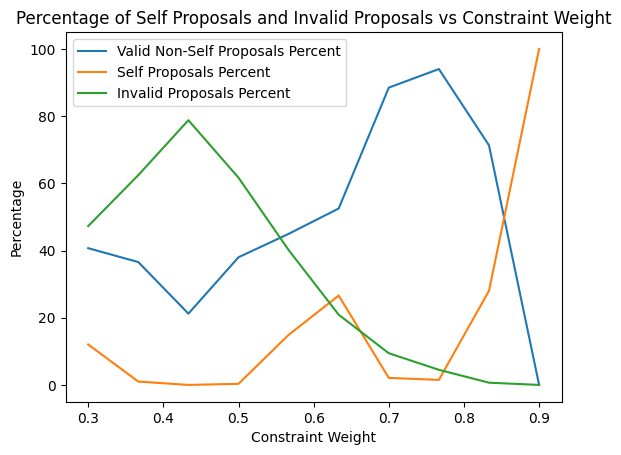

The maximum valid non-self proposal percentage is:  94.00210196921326  at gamma constraint:  0.7666666666666668


In [16]:

valid_non_self_proposals_percent_list_state_vector = 100 - np.array(self_proposals_percent_list_state_vector) - np.array(invalid_proposals_percent_list_state_vector)
plt.plot(gamma_constrains, valid_non_self_proposals_percent_list_state_vector, label="Valid Non-Self Proposals Percent")
plt.plot(gamma_constrains, self_proposals_percent_list_state_vector, label="Self Proposals Percent")
plt.plot(gamma_constrains, invalid_proposals_percent_list_state_vector, label="Invalid Proposals Percent")
plt.xlabel("Constraint Weight")
plt.ylabel("Percentage")
plt.title("Percentage of Self Proposals and Invalid Proposals vs Constraint Weight")
plt.legend()
plt.show()

best_constraint_weight = gamma_constrains[np.argmax(valid_non_self_proposals_percent_list_state_vector)]
print("The maximum valid non-self proposal percentage is: ", np.max(valid_non_self_proposals_percent_list_state_vector), " at gamma constraint: ", best_constraint_weight)



The above graph should look really interesting. At the far right, you should see the "perturbative regime", where the mixing becomes too small (or equivalently the constraint is too large) to excite the system away from  its initial configuration. Moving left, the system is excited to valid (blue) and invalid (green) configurations, before large oscillations appear from higher order effects. Infact, from this graph it isn't clear what a good amount of mixing is. Do you want lots of valid (but local and energetically bad) proposals, or do you want only a few very good proposals?

# Hamming weight plot

Plot cumulative hamming weight of each proposal to compare

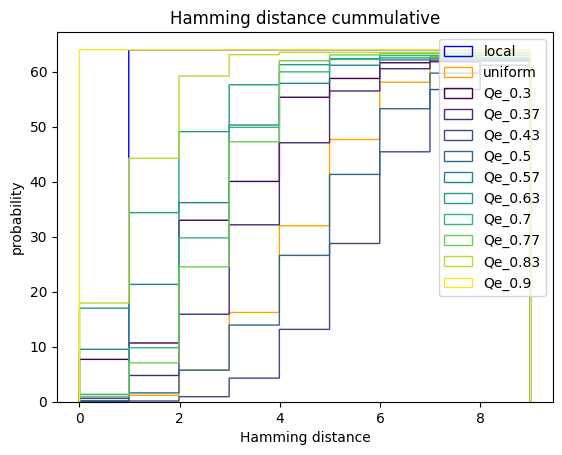

In [17]:


# plot histograms of hamming distances
weights_list_sv = [local_weights_sample, uniform_weights_sample] +    weights_list_state_vector
labels = ["local", "uniform"]+["Qe_"+str(np.round(lab,2)) for lab in gamma_constrains]
colors= ["blue", "orange"] + plt.cm.viridis(np.linspace(0, 1, len(gamma_constrains))).tolist()
for weights, label, color in zip(weights_list_sv, labels, colors):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend(loc = "upper right")

plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("probability")
plt.show()





# Energy difference plot

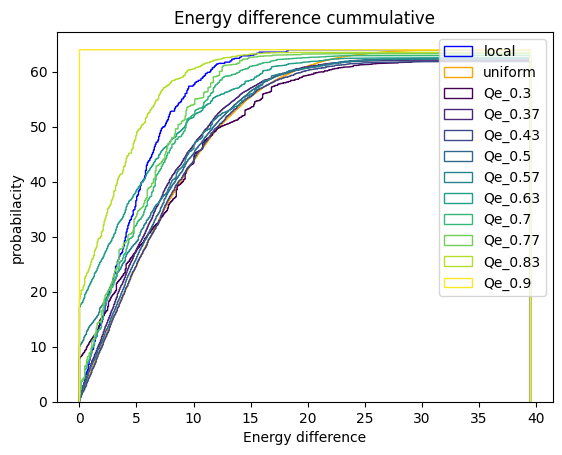

In [18]:
# plot energy difference histograms 
for weights, label, color in zip(weights_list_sv, labels, colors):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
plt.legend(loc = "upper right")
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("probabilacity")
plt.show()


# QeMCMC implementation

As it isn't actually very clear what a good amount of mixing is, lets sample over a range of values and see how the QeMCMC does.

In [62]:
from qemcmc.sampler.runners import ConstrainedMCMCRunner
from qemcmc.utils import plot_chains
from joblib import Parallel, delayed
temp = 0.1
steps = 200
runner = ConstrainedMCMCRunner(constraint_model, temp, constraint_checker_func)

In [70]:
uni_chains = []
uni_rejections = []
for rep in range(reps):
    classical_uniform_MCMC = ClassicalProposal(constraint_model, method="uniform")
    uni_chain, uni_rejection = runner.run(classical_uniform_MCMC, steps, initial_state=constraint_model.initial_state[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains.append(uni_chain)
    uni_rejections.append(uni_rejection)


# print average rejections per chain
avg_uni_rejections = np.mean(uni_rejections)/steps
print(f"Average constraint rejections per step: {avg_uni_rejections}")



Average constraint rejections per step: 0.867


In [69]:
loc_chains = []
loc_rejections = []
for rep in range(reps):
    classical_local_MCMC = ClassicalProposal(constraint_model, method="local")
    loc_chain, loc_rejection = runner.run(classical_local_MCMC, steps, initial_state=constraint_model.initial_state[rep], name="classical local MCMC", verbose=False, sample_frequency=1)
    loc_chains.append(loc_chain)
    loc_rejections.append(loc_rejection)

# print average rejections per chain
avg_loc_rejections = np.mean(loc_rejections)/steps
print(f"Average constraint rejections per step: {avg_loc_rejections}")

Average constraint rejections per step: 0.5529999999999999


In [65]:
m_ = 1 # How many subgroups in (optional) coarse graining
problem_weight = 0.1 #mixing_gamma = 1-(problem_weight + best_constraint_weight)
time = (5,15)#(1,20)
print("using best_constraint_weight: ", best_constraint_weight)
c_weight = best_constraint_weight
mixing_gamma = tuple(1-(problem_weight + np.array([c_weight+0.1, c_weight-0.3])))
if mixing_gamma[0] < 0:
    mixing_gamma = (0, mixing_gamma[1])
if mixing_gamma[1] < 0:
    print("Warning: best constraint weight is abnormally high, try playing around with problem weight or problem instance ")

coupling_weights_ = np.array([problem_weight, problem_weight, c_weight])
coupling_weights = coupling_weights_/(1-np.mean(mixing_gamma))
print("coupling weights: ", coupling_weights)
print("mixing gamma: ", mixing_gamma)
def run_qemcmc(rep, m, coupling_weights):
    quantum_proposal = QeProposal(constraint_model, gamma=mixing_gamma, time=time, m = m, coupling_weights = coupling_weights)
    return runner.run(quantum_proposal, steps, initial_state=constraint_model.initial_state[rep], name="QeMCMC", verbose=True, sample_frequency=1)


using best_constraint_weight:  0.7666666666666668
coupling weights:  [0.13043478 0.13043478 1.        ]
mixing gamma:  (np.float64(0.033333333333333215), np.float64(0.4333333333333331))


In [66]:

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep, m_, coupling_weights_) for rep in range(reps))

output = np.array(output)
qe_chains = output[:, 0]
Qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(Qe_rejection)/steps
print(f"Average constraint rejections per step: {avg_rejections}")
# should take <2 minutes

Average constraint rejections per step: 0.243


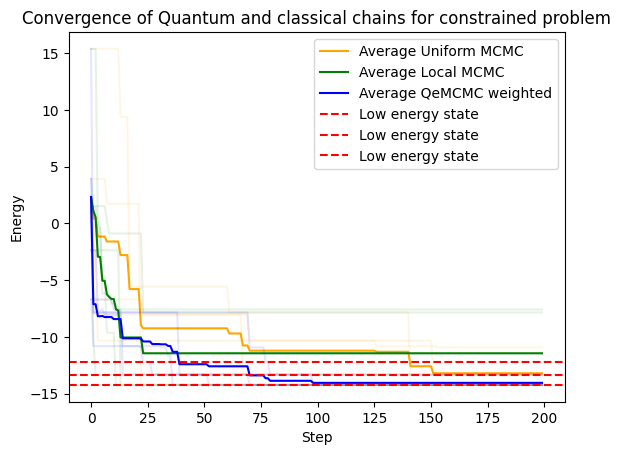

In [71]:
plot_chains(uni_chains, color = 'orange', label="Uniform MCMC")
plot_chains(loc_chains, color = 'green', label="Local MCMC")
plot_chains(qe_chains, color = 'blue', label="QeMCMC weighted")

lowest_energies, degeneracies, lowest_configs = constraint_model.get_lowest_energies(1000, return_configurations=True)
constrained_lowest_energies = []
for i in range(len(lowest_energies)):
    if degeneracies[i] > 1:
        for j in range(degeneracies[i]):
            if constraint_checker_func(lowest_configs[i][j]):
                constrained_lowest_energies.append(lowest_energies[i])
                #plt.axhline(lowest_energies[i], color="red", linestyle="--", label=f"Ground state energy (degeneracy {degeneracies[i]})")
    else:
        if constraint_checker_func(lowest_configs[i][0]):
            constrained_lowest_energies.append(lowest_energies[i])
            #plt.axhline(lowest_energies[i], color="red", linestyle="--", label="Ground state energy")
for i, energy in enumerate(constrained_lowest_energies):
    if i<3:
        plt.axhline(energy, color="red", linestyle="--", label=f"Low energy state")
        
plt.title("Convergence of Quantum and classical chains for constrained problem")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.legend()
#plt.xscale("log")
plt.show()